# # Project FORESIGHT — Stronger Model (LightGBM)
# Goal: Beat seasonal-naive baseline (WAPE ~31–32%)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit

# # Load weekly dataset

In [3]:
weekly = pd.read_csv("weekly_forecast_ready.csv")
weekly["week_start"] = pd.to_datetime(weekly["week_start"])
weekly = weekly.sort_values(["sku_id", "week_start"]).reset_index(drop=True)

print("Loaded:", weekly.shape)
print("Baseline WAPE was ~32.12% overall / 31.26% last year")

Loaded: (52400, 26)
Baseline WAPE was ~32.12% overall / 31.26% last year


# 1. Prepare features and target

In [4]:
feature_cols = [
    "lag_1", "lag_2", "lag_4", "lag_52",
    "roll_mean_4", "roll_mean_8", "roll_std_4",
    "weekofyear", "month", "quarter",
    "promo_days", "holiday_days",
    "avg_price", "on_hand", "lead_time", "reorder_point"
]

# Encode category
weekly["category_code"] = weekly["category"].astype("category").cat.codes
feature_cols.append("category_code")

target = "units_sold"

# Drop rows where key lags are still NaN (early history)
model_df = weekly.dropna(subset=["lag_1", "lag_4"]).copy()
print("Rows after dropping early NaNs:", len(model_df))

Rows after dropping early NaNs: 51600


# 2. Time-based train / test split (last 52 weeks = test)

In [5]:
cutoff = model_df["week_start"].max() - pd.Timedelta(weeks=52)
train = model_df[model_df["week_start"] < cutoff]
test  = model_df[model_df["week_start"] >= cutoff]

print(f"Train weeks: {train['week_start'].min().date()} → {train['week_start'].max().date()} ({len(train)} rows)")
print(f"Test  weeks: {test['week_start'].min().date()} → {test['week_start'].max().date()} ({len(test)} rows)")

X_train = train[feature_cols]
y_train = train[target]
X_test  = test[feature_cols]
y_test  = test[target]

Train weeks: 2021-09-06 → 2025-08-04 (41000 rows)
Test  weeks: 2025-08-11 → 2026-08-10 (10600 rows)


# 3. Train LightGBM

In [6]:
params = {
    "objective": "regression",
    "metric": "mae",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1,
    "n_estimators": 500,
    "random_state": 42
}

model = lgb.LGBMRegressor(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

print("Model trained.")

Model trained.


# # 4. Predictions

In [7]:
test = test.copy()
test["lgb_pred"] = model.predict(X_test)
test["lgb_pred"] = test["lgb_pred"].clip(lower=0)  # demand cannot be negative

# Also keep baseline for comparison
test["baseline_pred"] = test["baseline_pred"].fillna(0)

## 5. WAPE comparison

In [8]:
def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denom * 100

baseline_wape = wape(test["units_sold"], test["baseline_pred"])
lgb_wape      = wape(test["units_sold"], test["lgb_pred"])

print("\n" + "="*50)
print("MODEL COMPARISON (Last 52 weeks = Test)")
print("="*50)
print(f"Seasonal-Naive WAPE : {baseline_wape:.2f}%")
print(f"LightGBM WAPE       : {lgb_wape:.2f}%")
print(f"Improvement         : {baseline_wape - lgb_wape:.2f} points")

print("\nWAPE by category (LightGBM):")
for cat in sorted(test["category"].unique()):
    mask = test["category"] == cat
    score = wape(test.loc[mask, "units_sold"], test.loc[mask, "lgb_pred"])
    base  = wape(test.loc[mask, "units_sold"], test.loc[mask, "baseline_pred"])
    print(f"  {cat:<20}: LGB {score:.2f}%  |  Baseline {base:.2f}%")


MODEL COMPARISON (Last 52 weeks = Test)
Seasonal-Naive WAPE : 31.26%
LightGBM WAPE       : 19.96%
Improvement         : 11.29 points

WAPE by category (LightGBM):
  Decor               : LGB 18.77%  |  Baseline 29.10%
  Furniture           : LGB 19.01%  |  Baseline 28.97%
  Small Appliances    : LGB 24.41%  |  Baseline 40.58%


# # 6. Feature importance


Top features:
      feature  importance
        lag_1        1627
       lag_52        1620
      on_hand        1396
reorder_point        1389
        lag_2        1153
  roll_mean_8        1130
    avg_price         990
  roll_mean_4         917
        lag_4         915
    lead_time         913


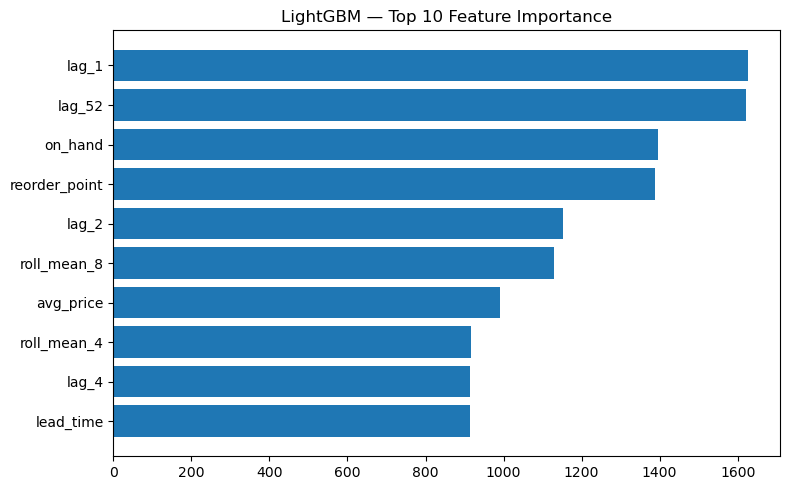

In [9]:
imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop features:")
print(imp.head(10).to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(imp["feature"].head(10)[::-1], imp["importance"].head(10)[::-1])
plt.title("LightGBM — Top 10 Feature Importance")
plt.tight_layout()
plt.show()

# # 7. Visual check — one SKU

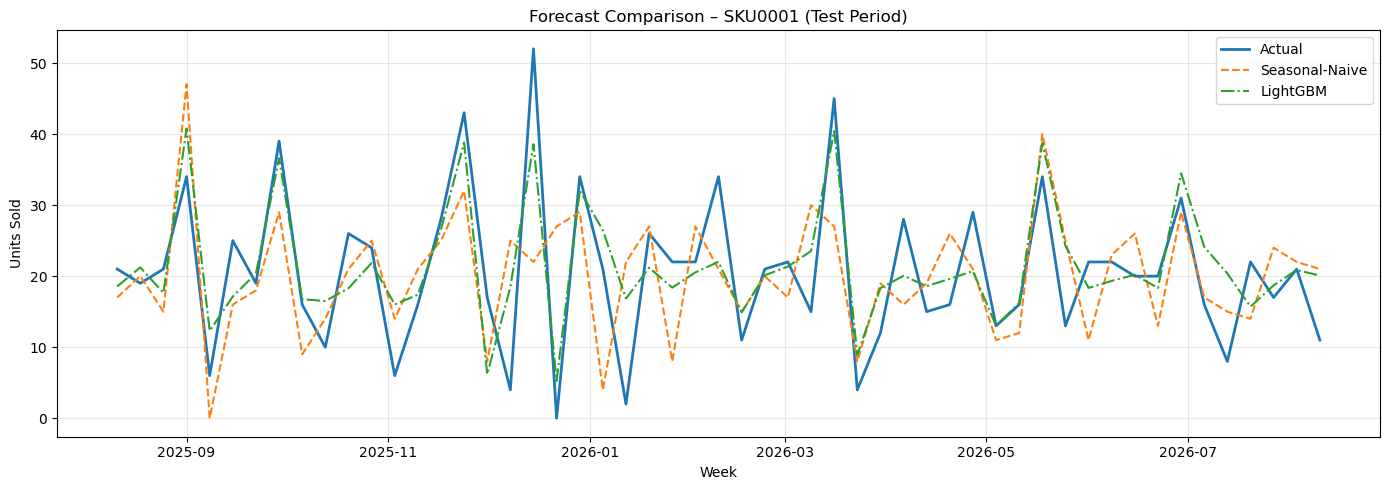

In [10]:
sku = "SKU0001"
sample = test[test["sku_id"] == sku]

if len(sample) > 0:
    plt.figure(figsize=(14, 5))
    plt.plot(sample["week_start"], sample["units_sold"], label="Actual", linewidth=2)
    plt.plot(sample["week_start"], sample["baseline_pred"], label="Seasonal-Naive", linestyle="--")
    plt.plot(sample["week_start"], sample["lgb_pred"], label="LightGBM", linestyle="-.")
    plt.title(f"Forecast Comparison – {sku} (Test Period)")
    plt.xlabel("Week")
    plt.ylabel("Units Sold")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## # 8. Save predictions

In [11]:
# Merge LGB predictions back to full weekly for later risk scoring
weekly = weekly.merge(
    test[["sku_id", "week_start", "lgb_pred"]],
    on=["sku_id", "week_start"],
    how="left"
)

weekly.to_csv("weekly_with_lgb_predictions.csv", index=False)
print("\nSaved: weekly_with_lgb_predictions.csv")
print("Done.")


Saved: weekly_with_lgb_predictions.csv
Done.
